<center>

## Calibration with NiO Porcess Time
</center>

In [3]:
# ================================================================================================== Import =================================================================================================================
import re
import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from k_factors import k_factors
from scipy.optimize import curve_fit
from datetime import datetime
from pathlib import Path
from matplotlib.ticker import MultipleLocator

In [4]:
# ==================================================================================================Load Data with Path ==================================================================================================

MainPath = Path.cwd()

folder = MainPath / "NiO_Process"
PlotPath = MainPath / "Plots"

def extract_proc(filepath):
    name = Path(filepath).stem
    
    match = re.search(r'Proc(\d+)', name)

    if match is None:
        raise ValueError(f"Could not extract Proc number from filename: {name}")

    return int(match.group(1))

# load and SORT files by angle
files = sorted(folder.glob("*.msa"), key=extract_proc)
s = hs.load(files[0]) # Load one spectrum to identify peaks and set elements/lines for all spectra

C:\Users\grego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\grego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
C:\Users\grego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is depre

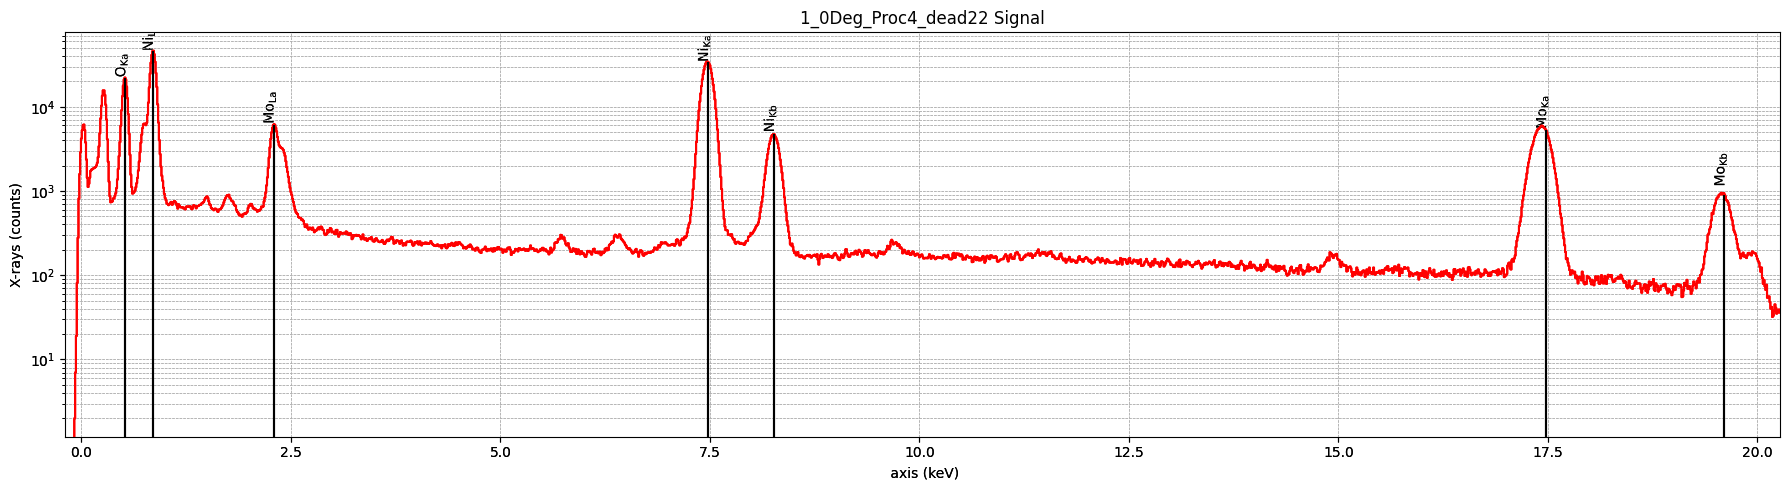

In [5]:
# ================================================================================================== Identify Peaks =================================================================================================================

s.set_elements(['O', 'Ni', 'Mo'])
s.set_lines(['O_Ka', 'Ni_Ka', 'Ni_Kb', 'Ni_La', 'Mo_Ka', 'Mo_Kb', 'Mo_La'])

s.plot(True)
fig = plt.gcf()
ax = plt.gca()
ax.grid(True, which="both", ls="--", lw=0.5)
ax.set_yscale("log") # Set y-axis to "linear", "log" or"symlog", scale for better visibility of peaks
fig.set_size_inches(18, 5)
fig.tight_layout()
    



Experimenting with Continues Background substraction

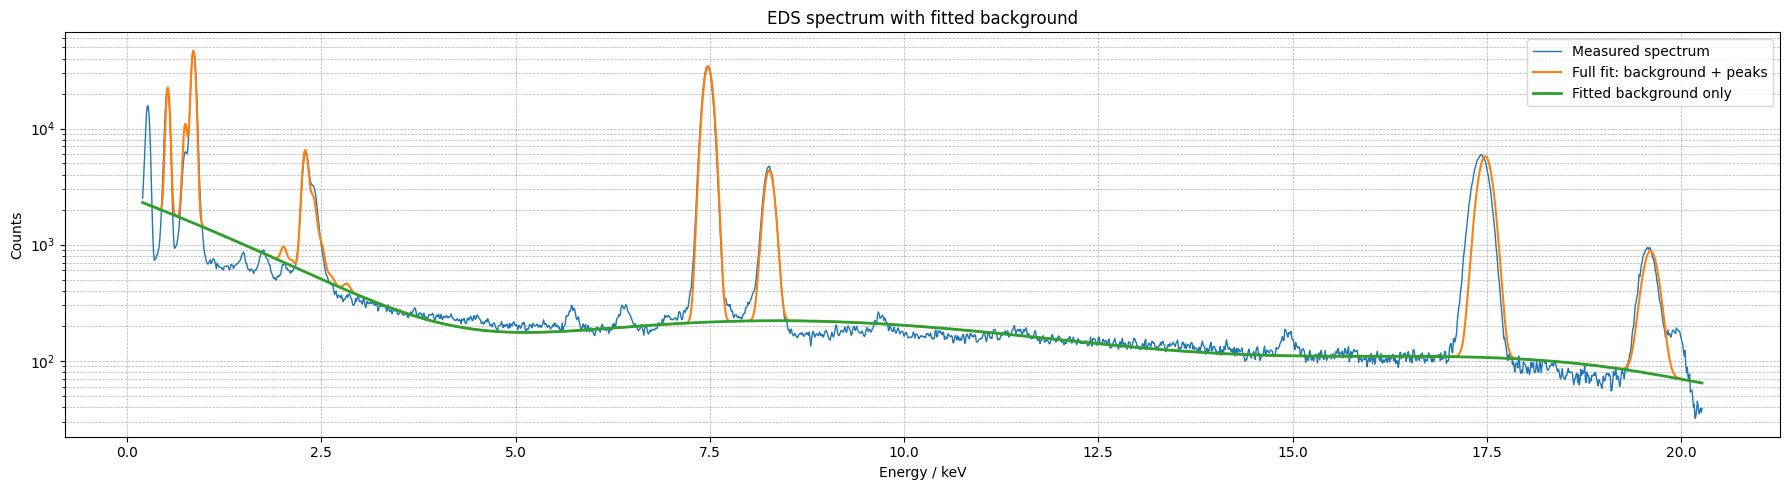

In [6]:
# ============================================================= Identify Peaks + Fit Model + Plot Fitted Background ==================================================================================================


# --- define elements and X-ray lines ---
s.set_elements(['O', 'Ni', 'Mo'])
s.set_lines(['O_Ka', 'Ni_Ka', 'Ni_Kb', 'Ni_La', 'Mo_Ka', 'Mo_Kb', 'Mo_La'])

# --- create and fit EDS model ---
m = s.create_model()
m.fit_background()  # fit background in the energy range from 0 to 20 keV
m.fit()

# --- get energy axis and measured spectrum ---
x = s.axes_manager.signal_axes[0].axis
y = s.data.astype(float)

# --- get full fitted model: background + peaks ---
full_fit = m.as_signal().data

# --- get fitted background only ---
m.disable_xray_lines()
background_fit = m.as_signal().data
m.enable_xray_lines()   # restore X-ray lines afterwards

# --- cut off negative energy values ---
mask = x >= 0.2

x_plot = x[mask]
y_plot = y[mask]
full_fit_plot = full_fit[mask]
background_fit_plot = background_fit[mask]

# --- plot measured spectrum, full fit, and fitted background ---
fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(x_plot, y_plot, label="Measured spectrum", lw=1)
ax.plot(x_plot, full_fit_plot, label="Full fit: background + peaks", lw=1.5)
ax.plot(x_plot, background_fit_plot, label="Fitted background only", lw=2)

# --- plot settings ---
ax.set_yscale("log")   # use "linear", "log", or "symlog"
ax.grid(True, which="both", ls="--", lw=0.5)
ax.set_xlabel("Energy / keV")
ax.set_ylabel("Counts")
ax.set_title("EDS spectrum with fitted background")
ax.legend()

fig.tight_layout()
plt.show()

<center>

# Background Window Positioning
</center>

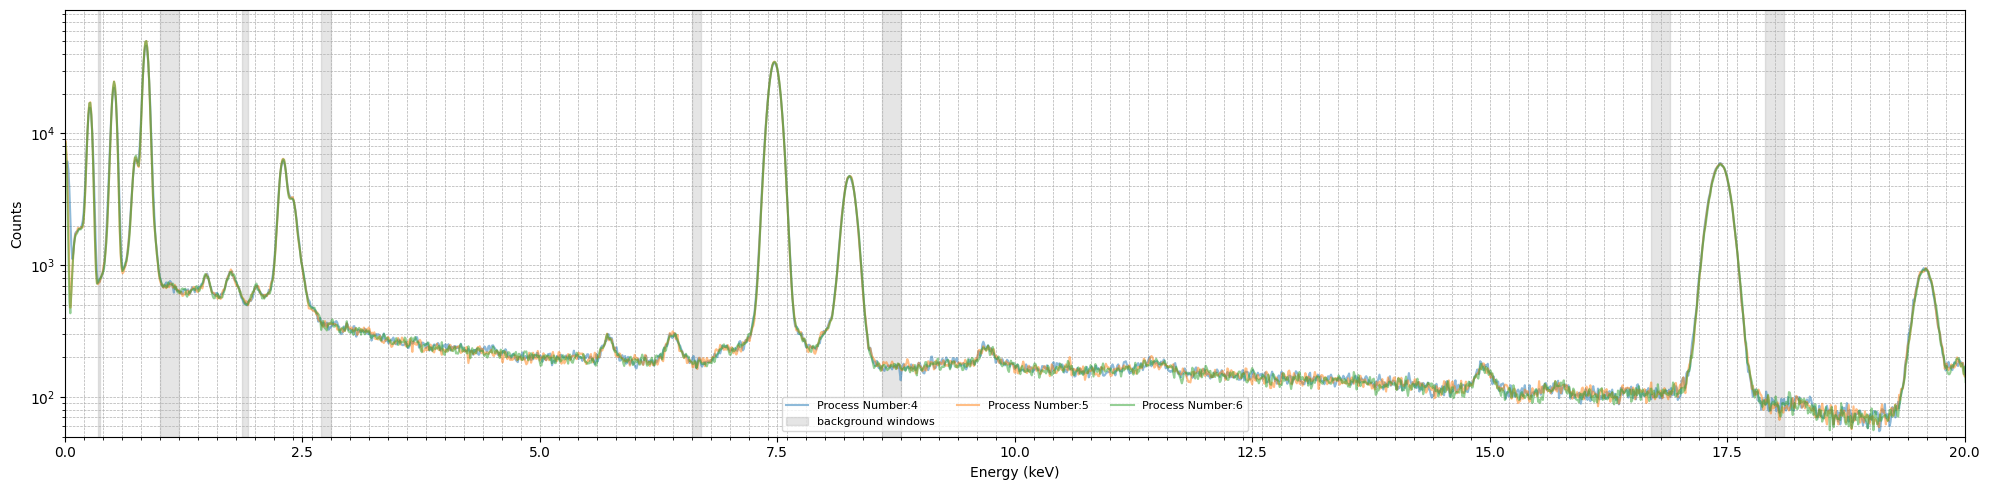

In [7]:
# ================================================================================================== Background Windows =================================================================================================================

fig, ax = plt.subplots(figsize=(20, 5))

for i, f in enumerate(files):
    s = hs.load(f)
    s.set_signal_type("EDS_TEM")
    s.set_elements(['O', 'Ni', 'Mo'])
    s.set_lines(['O_Ka', 'Ni_Ka', 'Ni_Kb', 'Mo_Ka'])

    x = s.axes_manager.signal_axes[0].axis
    y = s.data.astype(float)

    # O_Ka
    lmin_O, lmax_O = 0.35, 0.37
    rmin_O, rmax_O = 1.0, 1.2

    # Ni_Ka / Ni_Kb
    lmin_Ni, lmax_Ni = 6.6, 6.7
    rmin_Ni, rmax_Ni = 8.6, 8.8

    # Mo_Ka
    lmin_Mo, lmax_Mo = 16.7, 16.9
    rmin_Mo, rmax_Mo = 17.9, 18.1

    # Mo_La
    lmin_Mo_La, lmax_Mo_La = 1.87, 1.93
    rmin_Mo_La, rmax_Mo_La = 2.7, 2.8

    # # Exact windows used for Background estimation
    # x_Ni_bg_left = 7.28
    # x_Ni_bg_right = 7.65

    process = extract_proc(f)

    ax.plot(x, y, label=f"Process Number:{process}", alpha=0.5)

    # draw bw only once, because they are identical for all spectra
    if i == 0:
        # Ni peak windows
        ax.axvspan(lmin_Ni, lmax_Ni, color="grey", alpha=0.2, label="background windows")
        ax.axvspan(rmin_Ni, rmax_Ni, color="grey", alpha=0.2)

        # O peak windows
        ax.axvspan(lmin_O, lmax_O, color="grey", alpha=0.2)
        ax.axvspan(rmin_O, rmax_O, color="grey", alpha=0.2)

        # Mo peak windows
        ax.axvspan(lmin_Mo, lmax_Mo, color="grey", alpha=0.2)
        ax.axvspan(rmin_Mo, rmax_Mo, color="grey", alpha=0.2)

        # Mo_La peak windows
        ax.axvspan(lmin_Mo_La, lmax_Mo_La, color="grey", alpha=0.2)
        ax.axvspan(rmin_Mo_La, rmax_Mo_La, color="grey", alpha=0.2)

        # # Ni background windows
        # ax.axvline(x_Ni_bg_left, color="black", linestyle="--", label="Ni background windows")
        # ax.axvline(x_Ni_bg_right, color="black", linestyle="--") 

ax.set_yscale("log")
ax.set_ylim(bottom=50) # Set y-axis limits to better visualize peaks, adjust as needed
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.grid(True, which="both", ls="--", lw=0.5)
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
ax.set_xlim(0,20) # Set x-axis limits to focus on relevant energy range, adjust as needed
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

Keep Track of the -20 Degree line. 

Lower Energys almost not representable -> To much absorbtion

Higher Energys over representablet -> ???

<center>

# Gaussien Composition & Peak Area Calculation
</center>
Each peak needs 10^4 counts after Background substraction to be a good peak according to Willliams & Cater

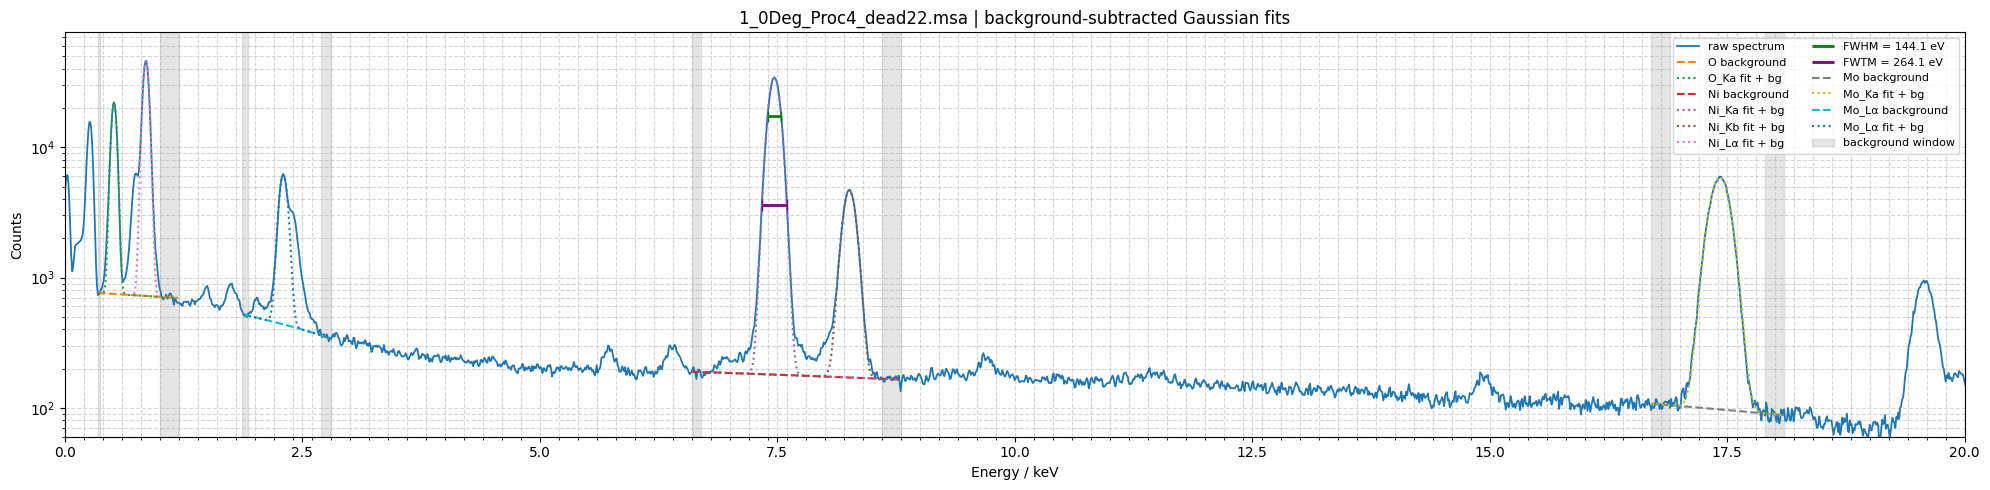

1_0Deg_Proc4_dead22.msa O_Ka=0.5189 keV, Ni_Ka=7.4710 keV, Ni_Kb=8.2601 keV, Ni_La=0.8553 keV, Mo_Ka=17.4224 keV, Mo_La=2.3021 keV, O_Ka=153421.1 Counts/Peak, Ni_Ka=525965.0 Counts/Peak, Ni_Kb=76103.9 Counts/Peak, Ni_La=359359.6 Counts/Peak, Mo_Ka=151198.5 Counts/Peak, Mo_La=63809.6 Counts/Peak


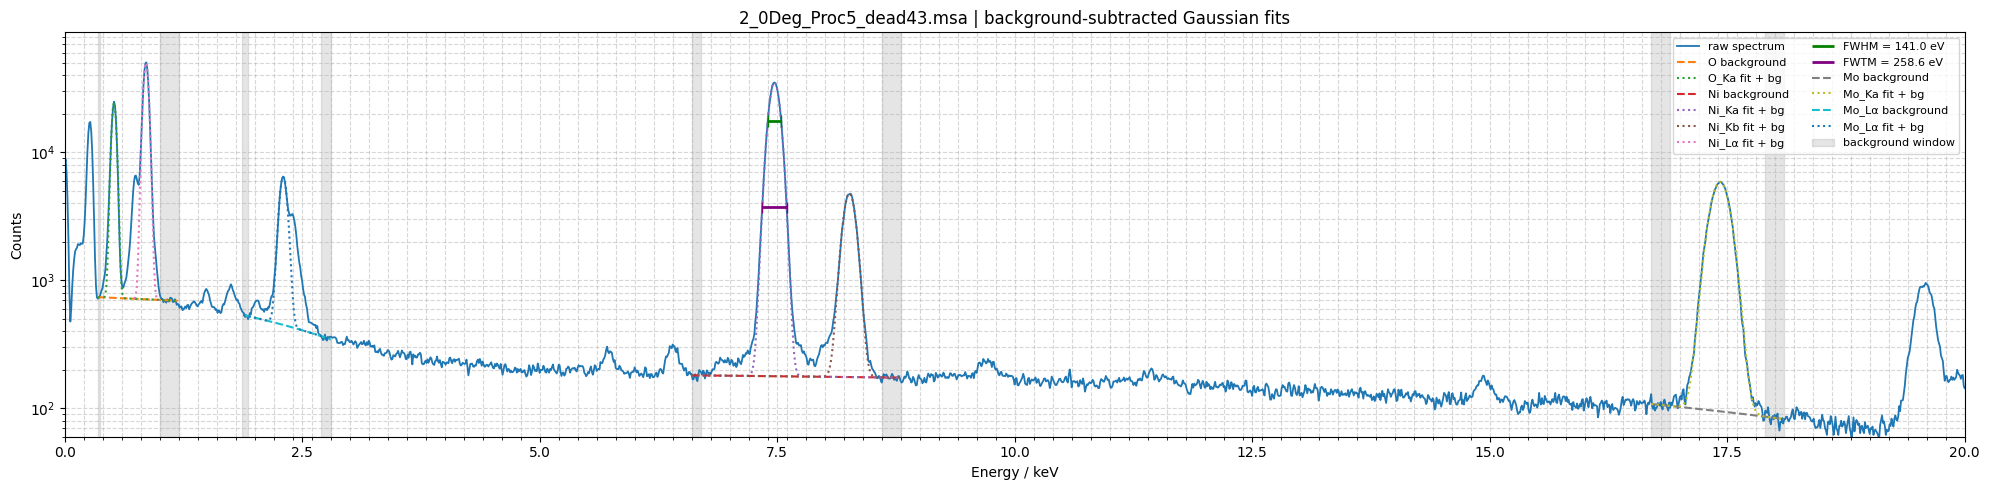

2_0Deg_Proc5_dead43.msa O_Ka=0.5193 keV, Ni_Ka=7.4714 keV, Ni_Kb=8.2607 keV, Ni_La=0.8556 keV, Mo_Ka=17.4240 keV, Mo_La=2.3015 keV, O_Ka=151669.7 Counts/Peak, Ni_Ka=524916.2 Counts/Peak, Ni_Kb=75626.0 Counts/Peak, Ni_La=356628.6 Counts/Peak, Mo_Ka=149595.8 Counts/Peak, Mo_La=61819.4 Counts/Peak


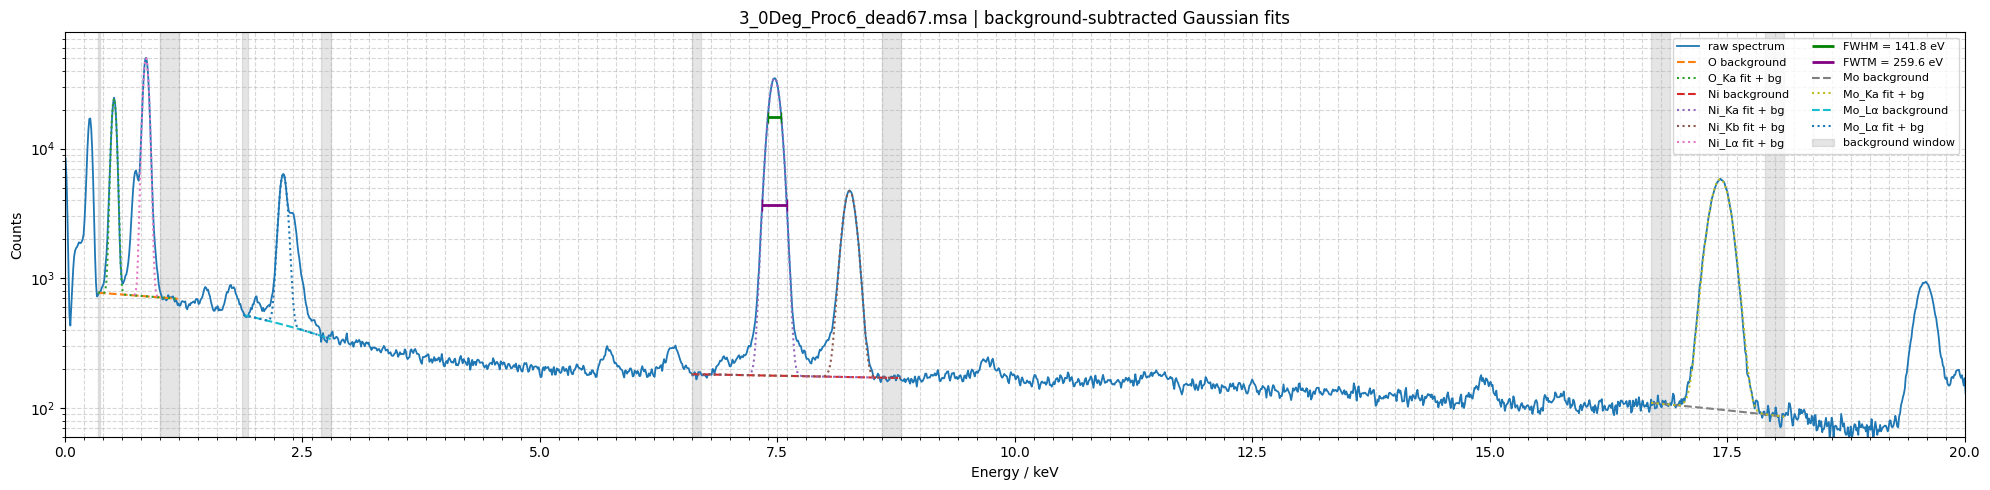

3_0Deg_Proc6_dead67.msa O_Ka=0.5196 keV, Ni_Ka=7.4724 keV, Ni_Kb=8.2621 keV, Ni_La=0.8558 keV, Mo_Ka=17.4265 keV, Mo_La=2.3016 keV, O_Ka=151605.2 Counts/Peak, Ni_Ka=526370.0 Counts/Peak, Ni_Kb=75667.0 Counts/Peak, Ni_La=357587.1 Counts/Peak, Mo_Ka=148381.3 Counts/Peak, Mo_La=61339.2 Counts/Peak


In [8]:
# ================================================================================================== Area of Gaussian ==================================================================================================

fit_results = []


def gauss(x, A, mu, sig):
    return A * np.exp(-(x - mu)**2 / (2 * sig**2))

def two_gauss(x, A1, mu1, sig1, A2, mu2, sig2):
    return gauss(x, A1, mu1, sig1) + gauss(x, A2, mu2, sig2)

def area_gauss(A, sig):
    return A * sig * np.sqrt(2 * np.pi)

def width_at_fraction(x, y, fraction):
    y0 = np.min(y)
    y = y - y0
    level = fraction * np.max(y)
    imax = np.argmax(y)

    left = np.where(y[:imax] < level)[0]
    right = np.where(y[imax:] < level)[0] + imax

    if len(left) == 0 or len(right) == 0:
        return np.nan, np.nan, np.nan, np.nan

    i1, i2 = left[-1], left[-1] + 1
    j2, j1 = right[0], right[0] - 1

    x_left = np.interp(level, [y[i1], y[i2]], [x[i1], x[i2]])
    x_right = np.interp(level, [y[j2], y[j1]], [x[j2], x[j1]])

    return x_right - x_left, x_left, x_right, level + y0


# ================================================================================================= Main loop over all spectra =================================================================================================

for f in files:

    # Load spectrum ================================================================================================================================================================================

    s = hs.load(f)
    s.set_signal_type("EDS_TEM")
    s.set_elements(["O", "Ni", "Mo"])
    s.set_lines(["O_Ka", "Ni_Ka", "Ni_Kb", "Ni_La", "Mo_Ka", "Mo_La"])

    x = s.axes_manager.signal_axes[0].axis
    y = s.data.astype(float)

    # Define fit ranges ================================================================================================================================================================================
   
    O_fit_min, O_fit_max = lmin_O, rmax_O
    Ni_fit_min, Ni_fit_max = lmin_Ni, rmax_Ni
    Ni_La_fit_min, Ni_La_fit_max = 0.80, 0.95
    Mo_fit_min, Mo_fit_max = lmin_Mo, rmax_Mo
    Mo_La_fit_min, Mo_La_fit_max = 2.2, 2.35

    # Create masks for fitting regions ================================================================================================================================================================================

    O_mask = (x >= O_fit_min) & (x <= O_fit_max)
    Ni_mask = (x >= Ni_fit_min) & (x <= Ni_fit_max)
    Ni_La_mask = (x >= Ni_La_fit_min) & (x <= Ni_La_fit_max)
    Mo_mask = (x >= Mo_fit_min) & (x <= Mo_fit_max)
    Mo_La_mask = (x >= Mo_La_fit_min) & (x <= Mo_La_fit_max)
    
    x_O, y_O = x[O_mask], y[O_mask]
    x_Ni, y_Ni = x[Ni_mask], y[Ni_mask]
    x_Ni_La, y_Ni_La = x[Ni_La_mask], y[Ni_La_mask]
    x_Mo, y_Mo = x[Mo_mask], y[Mo_mask]
    x_Mo_La, y_Mo_La = x[Mo_La_mask], y[Mo_La_mask]

    # Define background windows ================================================================================================================================================================================

    bg_mask_O = ((x >= lmin_O) & (x <= lmax_O)) | ((x >= rmin_O) & (x <= rmax_O))
    bg_mask_Ni = ((x >= lmin_Ni) & (x <= lmax_Ni)) | ((x >= rmin_Ni) & (x <= rmax_Ni))
    bg_mask_Ni_La = ((x >= lmin_O) & (x <= lmax_O)) | ((x >= rmin_O) & (x <= rmax_O))
    bg_mask_Mo = ((x >= lmin_Mo) & (x <= lmax_Mo)) | ((x >= rmin_Mo) & (x <= rmax_Mo))
    bg_mask_Mo_La = ((x >= lmin_Mo_La) & (x <= lmax_Mo_La)) | ((x >= rmin_Mo_La) & (x <= rmax_Mo_La))

    # Fit linear background ================================================================================================================================================================================

    p_O = np.polyfit(x[bg_mask_O], y[bg_mask_O], 1)
    p_Ni = np.polyfit(x[bg_mask_Ni], y[bg_mask_Ni], 1)
    p_Ni_La = np.polyfit(x[bg_mask_Ni_La], y[bg_mask_Ni_La], 1)
    p_Mo = np.polyfit(x[bg_mask_Mo], y[bg_mask_Mo], 1)
    p_Mo_La = np.polyfit(x[bg_mask_Mo_La], y[bg_mask_Mo_La], 1)

    bg_O = np.polyval(p_O, x_O)
    bg_Ni = np.polyval(p_Ni, x_Ni)
    bg_Ni_La = np.polyval(p_Ni_La, x_Ni_La)
    bg_Mo = np.polyval(p_Mo, x_Mo)
    bg_Mo_La = np.polyval(p_Mo_La, x_Mo_La)

    # Background subtraction ================================================================================================================================================================================

    y_O_sub = np.clip(y_O - bg_O, 0, None)
    y_Ni_sub = np.clip(y_Ni - bg_Ni, 0, None)
    y_Ni_La_sub = np.clip(y_Ni_La - bg_Ni_La, 0, None)
    y_Mo_sub = np.clip(y_Mo - bg_Mo, 0, None)
    y_Mo_La_sub = np.clip(y_Mo_La - bg_Mo_La, 0, None)

    # Gaussian fits ================================================================================================================================================================================

    # O Kα
    p0_O = [y_O_sub.max(), 0.525, 0.035]
    bounds_O = ([0, 0.45, 0.005], [np.inf, 0.60, 0.12])
    popt_O, _ = curve_fit(gauss, x_O, y_O_sub, p0=p0_O, bounds=bounds_O, maxfev=50000)
    A_O_Ka, mu_O_Ka, sig_O_Ka = popt_O

    # Mo Kα
    p0_Mo = [y_Mo_sub.max(), 17.42, 0.10]
    bounds_Mo = ([0, 17.20, 0.01], [np.inf, 17.60, 0.30])
    popt_Mo, _ = curve_fit(gauss, x_Mo, y_Mo_sub, p0=p0_Mo, bounds=bounds_Mo, maxfev=50000)
    A_Mo_Ka, mu_Mo_Ka, sig_Mo_Ka = popt_Mo

    # Mo Lα
    p0_Mo_La = [y_Mo_La_sub.max(), 2.29, 0.05]
    bounds_Mo_La = ([0, 2.20, 0.01], [np.inf, 2.40, 0.20])
    popt_Mo_La, _ = curve_fit(gauss, x_Mo_La, y_Mo_La_sub, p0=p0_Mo_La, bounds=bounds_Mo_La, maxfev=50000)
    A_Mo_La, mu_Mo_La, sig_Mo_La = popt_Mo_La
    
    # Ni Lα
    p0_Ni_La = [y_Ni_La_sub.max(), 0.85, 0.05]
    bounds_Ni_La = ([0, 0.80, 0.01], [np.inf, 0.95, 0.20])
    popt_Ni_La, _ = curve_fit(gauss, x_Ni_La, y_Ni_La_sub, p0=p0_Ni_La, bounds=bounds_Ni_La, maxfev=50000)
    A_Ni_La, mu_Ni_La, sig_Ni_La = popt_Ni_La

    # Ni Kα + Ni Kβ
    p0_Ni = [y_Ni_sub.max(), 7.47, 0.070, y_Ni_sub.max() * 0.8, 8.26, 0.070]
    bounds_Ni = ([0, 7.30, 0.01, 0, 8.05, 0.01], [np.inf, 7.65, 0.25, np.inf, 8.45, 0.25])
    popt_Ni, _ = curve_fit(two_gauss, x_Ni, y_Ni_sub, p0=p0_Ni, bounds=bounds_Ni, maxfev=50000)
    A_Ni_Ka, mu_Ni_Ka, sig_Ni_Ka, A_Ni_Kb, mu_Ni_Kb, sig_Ni_Kb = popt_Ni

    

    # Optional test: make Gaussian broader without affecting data-based FWHM/FWTM
    # sig_Ni_Ka *= 2

    # Data-based FWHM, FWTM and shape factor for Ni Kα

    Ni_Ka_mask = (x_Ni >= mu_Ni_Ka - 0.4) & (x_Ni <= mu_Ni_Ka + 0.4)
    x_Ni_Ka_only = x_Ni[Ni_Ka_mask]
    y_Ni_Ka_only = y_Ni_sub[Ni_Ka_mask]

    FWHM_Ni_Ka_data, x_FWHM_left, x_FWHM_right, y_FWHM_level = width_at_fraction(x_Ni_Ka_only, y_Ni_Ka_only, 0.5)
    FWTM_Ni_Ka_data, x_FWTM_left, x_FWTM_right, y_FWTM_level = width_at_fraction(x_Ni_Ka_only, y_Ni_Ka_only, 0.1)

    # Peak areas ================================================================================================================================================================================

    KeV_per_channel = 1 / s.axes_manager.signal_axes[0].scale

    area_O_Ka = area_gauss(A_O_Ka, sig_O_Ka) * KeV_per_channel
    area_Ni_Ka = area_gauss(A_Ni_Ka, sig_Ni_Ka) * KeV_per_channel
    area_Ni_Kb = area_gauss(A_Ni_Kb, sig_Ni_Kb) * KeV_per_channel
    area_Ni_La = area_gauss(A_Ni_La, sig_Ni_La) * KeV_per_channel
    area_Mo_Ka = area_gauss(A_Mo_Ka, sig_Mo_Ka) * KeV_per_channel
    area_Mo_La = area_gauss(A_Mo_La, sig_Mo_La) * KeV_per_channel

    # Store results ================================================================================================================================================================================

    fit_results.append({
        "file": f,
        "process": extract_proc(f),

        "O_Ka_mu": mu_O_Ka,
        "Ni_Ka_mu": mu_Ni_Ka,
        "Ni_Kb_mu": mu_Ni_Kb,
        "Ni_La_mu": mu_Ni_La,
        "Mo_Ka_mu": mu_Mo_Ka,
        "Mo_La_mu": mu_Mo_La,

        "O_Ka_area": area_O_Ka,
        "Ni_Ka_area": area_Ni_Ka,
        "Ni_Kb_area": area_Ni_Kb,
        "Ni_La_area": area_Ni_La,
        "Mo_Ka_area": area_Mo_Ka,
        "Mo_La_area": area_Mo_La,

        "O_background_windows": (lmin_O, lmax_O, rmin_O, rmax_O),
        "Ni_background_windows": (lmin_Ni, lmax_Ni, rmin_Ni, rmax_Ni),
        "Mo_background_windows": (lmin_Mo, lmax_Mo, rmin_Mo, rmax_Mo),
        "Mo_La_background_windows": (lmin_Mo_La, lmax_Mo_La, rmin_Mo_La, rmax_Mo_La),

        "O_background_poly": p_O,
        "Ni_background_poly": p_Ni,
        "Ni_La_background_poly": p_Ni_La,
        "Mo_background_poly": p_Mo,
        "Mo_La_background_poly": p_Mo_La,

        "O_Ka_sig": sig_O_Ka,
        "Ni_Ka_sig": sig_Ni_Ka,
        "Ni_Kb_sig": sig_Ni_Kb,
        "Ni_La_sig": sig_Ni_La,
        "Mo_Ka_sig": sig_Mo_Ka,
        "Mo_La_sig": sig_Mo_La,

        "Ni_Ka_FWHM_data": FWHM_Ni_Ka_data,
        "Ni_Ka_FWTM_data": FWTM_Ni_Ka_data,
    })

    # ----------------------------------------------------------------------------------------------
    # Plot spectrum, background and Gaussian fits
    # ----------------------------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(20, 5))
    ax.plot(x, y, label="raw spectrum", linewidth=1.3)

    # O Kα plot
    xO_plot = x[(x >= lmin_O) & (x <= rmax_O)]
    bgO_plot = np.polyval(p_O, xO_plot)
    O_Ka_plot = gauss(xO_plot, A_O_Ka, mu_O_Ka, sig_O_Ka)

    ax.plot(xO_plot, bgO_plot, "--", label="O background")
    ax.plot(xO_plot, bgO_plot + O_Ka_plot, ":", label="O_Ka fit + bg")

    # Ni Kα / Kβ plot
    xNi_plot = x[(x >= lmin_Ni) & (x <= rmax_Ni)]
    bgNi_plot = np.polyval(p_Ni, xNi_plot)
    Ni_Ka_plot = gauss(xNi_plot, A_Ni_Ka, mu_Ni_Ka, sig_Ni_Ka)
    Ni_Kb_plot = gauss(xNi_plot, A_Ni_Kb, mu_Ni_Kb, sig_Ni_Kb)

    ax.plot(xNi_plot, bgNi_plot, "--", label="Ni background")
    ax.plot(xNi_plot, bgNi_plot + Ni_Ka_plot, ":", label="Ni_Ka fit + bg")
    ax.plot(xNi_plot, bgNi_plot + Ni_Kb_plot, ":", label="Ni_Kb fit + bg")

    # Ni Lα plot
    xNi_La_plot = x[(x >= 0.73) & (x <= 1.00)]
    bgNi_La_plot = np.polyval(p_Ni_La, xNi_La_plot)
    Ni_La_plot = gauss(xNi_La_plot, A_Ni_La, mu_Ni_La, sig_Ni_La)

    # ax.plot(xNi_La_plot, bgNi_La_plot, "--", label="Ni_Lα background")
    ax.plot(xNi_La_plot, bgNi_La_plot + Ni_La_plot, ":", label="Ni_Lα fit + bg")

    # FWHM / FWTM markers for Ni Kα
    y_FWHM_plot = np.polyval(p_Ni, (x_FWHM_left + x_FWHM_right) / 2) + y_FWHM_level
    y_FWTM_plot = np.polyval(p_Ni, (x_FWTM_left + x_FWTM_right) / 2) + y_FWTM_level

    ax.hlines(y_FWHM_plot, x_FWHM_left, x_FWHM_right, color="green", linewidth=2, label=f"FWHM = {FWHM_Ni_Ka_data*1000:.1f} eV")
    ax.hlines(y_FWTM_plot, x_FWTM_left, x_FWTM_right, color="purple", linewidth=2, label=f"FWTM = {FWTM_Ni_Ka_data*1000:.1f} eV")
    ax.vlines([x_FWHM_left, x_FWHM_right], y_FWHM_plot*0.9, y_FWHM_plot*1.1, color="green", linewidth=1)
    ax.vlines([x_FWTM_left, x_FWTM_right], y_FWTM_plot*0.9, y_FWTM_plot*1.1, color="purple", linewidth=1)

    # Mo Kα plot
    xMo_plot = x[(x >= lmin_Mo) & (x <= rmax_Mo)]
    bgMo_plot = np.polyval(p_Mo, xMo_plot)
    Mo_Ka_plot = gauss(xMo_plot, A_Mo_Ka, mu_Mo_Ka, sig_Mo_Ka)

    ax.plot(xMo_plot, bgMo_plot, "--", label="Mo background")
    ax.plot(xMo_plot, bgMo_plot + Mo_Ka_plot, ":", label="Mo_Ka fit + bg")

    # Mo Lα plot
    xMo_La_plot = x[(x >= lmin_Mo_La) & (x <= rmax_Mo_La)]
    bgMo_La_plot = np.polyval(p_Mo_La, xMo_La_plot)
    Mo_La_plot = gauss(xMo_La_plot, A_Mo_La, mu_Mo_La, sig_Mo_La)

    ax.plot(xMo_La_plot, bgMo_La_plot, "--", label="Mo_Lα background")
    ax.plot(xMo_La_plot, bgMo_La_plot + Mo_La_plot, ":", label="Mo_Lα fit + bg")

    # Background windows
    ax.axvspan(lmin_O, lmax_O, color="grey", alpha=0.2, label="background window")
    ax.axvspan(rmin_O, rmax_O, color="grey", alpha=0.2)
    ax.axvspan(lmin_Ni, lmax_Ni, color="grey", alpha=0.2)
    ax.axvspan(rmin_Ni, rmax_Ni, color="grey", alpha=0.2)
    ax.axvspan(lmin_Mo, lmax_Mo, color="grey", alpha=0.2)
    ax.axvspan(rmin_Mo, rmax_Mo, color="grey", alpha=0.2)
    ax.axvspan(lmin_Mo_La, lmax_Mo_La, color="grey", alpha=0.2)
    ax.axvspan(rmin_Mo_La, rmax_Mo_La, color="grey", alpha=0.2)
    # ax.axvline(x_Ni_bg_left, color="black", linestyle="--", label="Ni background window")  
    # ax.axvline(x_Ni_bg_right, color="black", linestyle="--")    

    # Plot style
    ax.set_xlabel("Energy / keV")
    ax.set_ylabel("Counts")
    ax.set_title(f"{f.name} | background-subtracted Gaussian fits")
    ax.set_yscale("log")
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.set_xlim(0, 20)
    ax.set_ylim(bottom=60)
    ax.legend(ncol=2, fontsize=8)

    plt.tight_layout()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    # Print result summary

    print(
        f"{f.name:15} "
        f"O_Ka={mu_O_Ka:.4f} keV, "
        f"Ni_Ka={mu_Ni_Ka:.4f} keV, "
        f"Ni_Kb={mu_Ni_Kb:.4f} keV, "
        f"Ni_La={mu_Ni_La:.4f} keV, "
        f"Mo_Ka={mu_Mo_Ka:.4f} keV, "
        f"Mo_La={mu_Mo_La:.4f} keV, "
        f"O_Ka={area_O_Ka:.1f} Counts/Peak, "
        f"Ni_Ka={area_Ni_Ka:.1f} Counts/Peak, "
        f"Ni_Kb={area_Ni_Kb:.1f} Counts/Peak, "
        f"Ni_La={area_Ni_La:.1f} Counts/Peak, "
        f"Mo_Ka={area_Mo_Ka:.1f} Counts/Peak, "
        f"Mo_La={area_Mo_La:.1f} Counts/Peak"
    )

<center>

# Calibration of Scale & Offset 
</center>

Following the Spectrum will be Calibarated with the The Gallium  L-alpha and the K-alpha peak. 
First the first peak will be shifted to the expected spot. That the Energy of L-alpha peak matches the Literature values. Then the bin width, which is before 2eV will be adjusted that also K-alpha peak matches the Literature values. Afterwards the new Offset value and the new Binwidth will be printed.

Idealy the claibration will be done with the a calibration Sample like NiO. The peaks should idealy be spread far from each other and be relativly isolated. 

In [9]:
# ================================================================================================== Calibration of Y-Scale =================================================================================================================

calibrated_spectra = []

#Energy calibration using the measured peak positions of O_Ka and Mo_Ka, which are well-known reference lines in EDS spectra. We will apply a linear calibration to adjust the energy scale of each spectrum so that the measured peak positions match the true energies of these lines.
E_O_Ka_true = s._get_line_energy("O_Ka")
E_Mo_Ka_true = s._get_line_energy("Mo_Ka")
print(f"Amount of Channels: {s.axes_manager.signal_axes[0].size}, Channel Width: {s.axes_manager.signal_axes[0].scale:.6f} keV/channel")

for fit in fit_results:
    f = fit["file"]

    s = hs.load(f)
    s.set_signal_type("EDS_TEM")

    ax = s.axes_manager.signal_axes[0]

    # measured peak positions from Gaussian fits
    E_O_Ka_meas = fit["O_Ka_mu"]
    E_Mo_Ka_meas = fit["Mo_Ka_mu"]

    # linear calibration: E_true = a * E_meas + b
    a = (E_Mo_Ka_true - E_O_Ka_true) / (E_Mo_Ka_meas - E_O_Ka_meas)
    b = E_O_Ka_true - a * E_O_Ka_meas

    old_scale = ax.scale
    old_offset = ax.offset
    ax.scale = old_scale * a
    ax.offset = a * old_offset + b

    calibrated_spectra.append((f, s))

    print(f"{f.name:12}  " f"O_Ka_meas={E_O_Ka_meas:.4f} keV, " f"Mo_Ka_meas={E_Mo_Ka_meas:.4f} keV   " f"new bin_width={ax.scale:.6f} keV/bin, " f"new offset={ax.offset:.6f} keV")

Amount of Channels: 2048, Channel Width: 0.010000 keV/channel
1_0Deg_Proc4_dead22.msa  O_Ka_meas=0.5189 keV, Mo_Ka_meas=17.4224 keV   new bin_width=0.010030 keV/bin, new offset=-0.196181 keV
2_0Deg_Proc5_dead43.msa  O_Ka_meas=0.5193 keV, Mo_Ka_meas=17.4240 keV   new bin_width=0.010029 keV/bin, new offset=-0.196485 keV
3_0Deg_Proc6_dead67.msa  O_Ka_meas=0.5196 keV, Mo_Ka_meas=17.4265 keV   new bin_width=0.010028 keV/bin, new offset=-0.196693 keV


$$
\frac{C_{\mathrm{O}}}{C_{\mathrm{N}}} = k_{\mathrm{O/Ni}} \cdot \frac{A_{\mathrm{O}}}{A_{\mathrm{Ni}}}
$$
With C as the Composition and A as Area below the peak But this this the weighted composition not the Atomic composition 
$$
k_{\mathrm{O/Ni}}=\frac{k_{\mathrm{O/Si}}}{k_{\mathrm{Ni/Si}}} \cdot CalibrationFactor
$$
For Atomic Composition you need to multiply the inversed Mass ratio
$$
CalibrationFactor \approx \frac{Atomic Mass Nickl}{Atomic Mass Oxigen}=\frac{58.70}{16.00}=3.66875
$$
But the calibration will be slightly adapted in that way that the coomposition  averages about

<center>

# Quantification or k-factor dependence of the Holder X-Tilt
</center>

k_(O_Ka/Ni_Ka) = 2.085 , k_(Ni_Ka/O_Ka) = 1.27 , k_(O_Ka/Ni_Ka)_Calibrated = 6.02310531496063

1_0Deg_Proc4_dead22.msa  Ni_Composition: 36.27 at.%, O_Composition: 63.73 at.%   Ni_Ka_Area=525965.0, O_Ka_Area=153421.1, O_Ka/Ni_Ka=0.292
2_0Deg_Proc5_dead43.msa  Ni_Composition: 36.49 at.%, O_Composition: 63.51 at.%   Ni_Ka_Area=524916.2, O_Ka_Area=151669.7, O_Ka/Ni_Ka=0.289
3_0Deg_Proc6_dead67.msa  Ni_Composition: 36.57 at.%, O_Composition: 63.43 at.%   Ni_Ka_Area=526370.0, O_Ka_Area=151605.2, O_Ka/Ni_Ka=0.288

AVERAGE     Ni_Composition: 36.44 at.%, O_Composition: 63.56 at.%   Ni_Ka_Area=525750.4, O_Ka_Area=152232.0, O_Ka/Ni_Ka=0.290


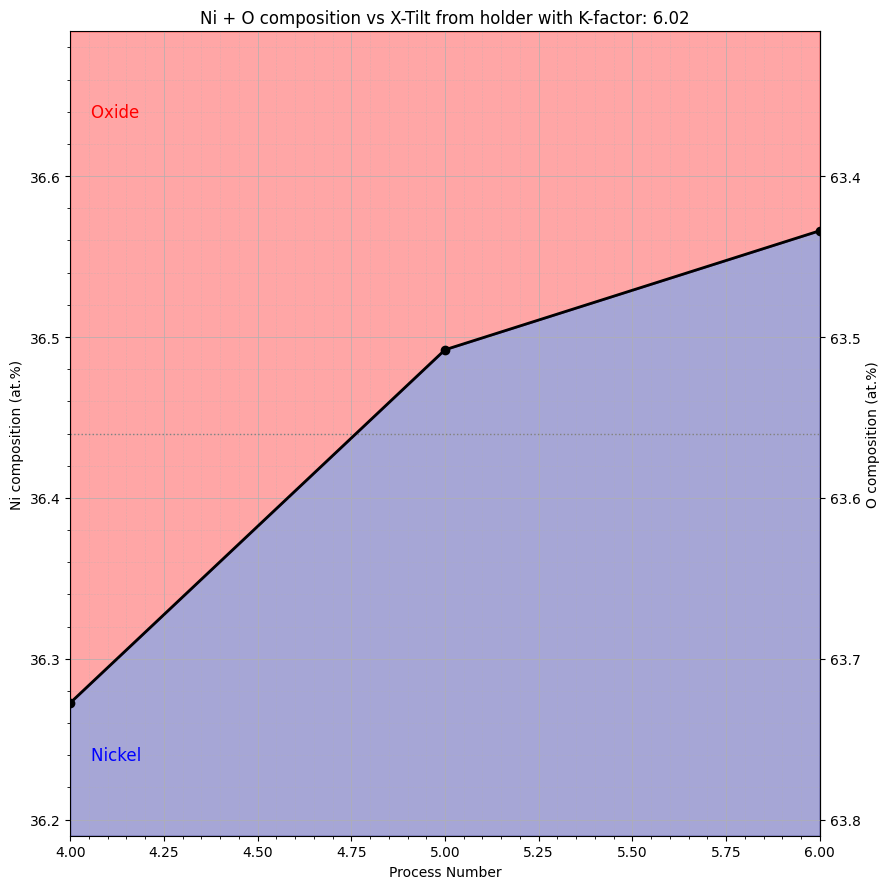

In [10]:
# ================================================================================================== Quantification with k-factors & Composition Plot =================================================================================================================

results = []

# #reload only if you update the k_factors, otherwise you can just import it once at the top of the notebook
# import importlib
# import organized.k_factors as kf_module
# importlib.reload(kf_module)
# k_factors = kf_module.k_factors

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE

Calibration_Factor =3.66875 # Mass ratio of Ni and O 58.70/16.00 = 3.66875

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE 

k_ONi= (k_factors["O_Ka"] / k_factors["Ni_Ka"]) * Calibration_Factor


print("k_(O_Ka/Ni_Ka) =", k_factors["O_Ka"], ", k_(Ni_Ka/O_Ka) =", k_factors["Ni_Ka"], ", k_(O_Ka/Ni_Ka)_Calibrated =", k_ONi)
print()

# calculate composition for each fit result

for fit in fit_results:
    area_ni = fit["Ni_Ka_area"]
    area_o = fit["O_Ka_area"]

    Ni_Composition = 1
    O_Composition = k_ONi * (area_o / area_ni) * Ni_Composition

    Ni_comp_final = Ni_Composition / (Ni_Composition + O_Composition) * 100
    O_comp_final = O_Composition / (Ni_Composition + O_Composition) * 100
    

    results.append({
        "file": fit["file"].name,
        "process": fit["process"],
        "Ni_Ka": area_ni,
        "O_Ka": area_o,
        "Ni_comp": Ni_comp_final,
        "O_comp": O_comp_final,
    })

    print(
        f"{fit['file'].name:10}  "
        f"Ni_Composition: {Ni_comp_final:.2f} at.%, "
        f"O_Composition: {O_comp_final:.2f} at.%   "
        f"Ni_Ka_Area={area_ni:.1f}, "
        f"O_Ka_Area={area_o:.1f}, "
        f"O_Ka/Ni_Ka={area_o/area_ni:.3f}"
    )

ni_avg = np.mean([r["Ni_comp"] for r in results])
o_avg = np.mean([r["O_comp"] for r in results])
ni_area_avg = np.mean([r["Ni_Ka"] for r in results])
o_area_avg = np.mean([r["O_Ka"] for r in results])

print()
print(
    f"{'AVERAGE':10}  "
    f"Ni_Composition: {ni_avg:.2f} at.%, "
    f"O_Composition: {o_avg:.2f} at.%   "
    f"Ni_Ka_Area={ni_area_avg:.1f}, "
    f"O_Ka_Area={o_area_avg:.1f}, "
    f"O_Ka/Ni_Ka={o_area_avg/ni_area_avg:.3f}"
)

# ================================================================================================== Angle Dependence Composition Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results = sorted(results, key=lambda r: r["process"])

process = [r["process"] for r in results]
ga = [r["Ni_comp"] for r in results]

fig, ax1 = plt.subplots(figsize=(9, 9))

center = 36.44
CenteringRange = 0.25
ymin = center - CenteringRange
ymax = center + CenteringRange


ax1.set_ylim(ymin, ymax)
ax1.set_xlim(4, 6)

ymin, ymax = ax1.get_ylim()

# fill ABOVE the curve
ax1.fill_between(process, ga, ymax, color="red", alpha=0.35)

# fill BELOW the curve
ax1.fill_between(process, ga, ymin, color="darkblue", alpha=0.35)

# main curve
ax1.plot(process, ga, marker="o", linewidth=2, color="black", zorder=3)

# axes and labels
ax1.set_xlabel("Process Number")
ax1.set_ylabel("Ni composition (at.%)")
ax1.set_title(f"Ni + O composition vs X-Tilt from holder with K-factor: {k_ONi:.2f}")

# grid
ax1.minorticks_on()
ax1.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax1.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)

# symmetry and center line
ax1.axvline(0, color="grey", linestyle="--", linewidth=1)
ax1.axhline(center, color="grey", linestyle=":", linewidth=1)

# right axis = As = 100 - Ga
secax = ax1.secondary_yaxis(
    'right',
    functions=(lambda y: 100 - y, lambda y: 100 - y)
)
secax.set_ylabel("O composition (at.%)")

# labels
ax1.text(min(process), center + 4*CenteringRange/5, "    Oxide", fontsize=12, color="red", va="center")
ax1.text(min(process), center - 4*CenteringRange/5, "    Nickel", fontsize=12, color="blue", va="center")

plt.tight_layout()
# plt.savefig(PlotPath / f"CompositionVsAngle_{timestamp}.pdf") # uncomment to save plot as PDF
plt.show()

k_(O_Ka/Ni_Ka) = 2.085 , k_(Ni_Ka/O_Ka) = 1.27 , k_(O_Ka/Ni_Ka)_Calibrated = 6.02310531496063

1_0Deg_Proc4_dead22.msa  Ni_Ka_Area=525965.0, O_Ka_Area=153421.1, O_Ka/Ni_Ka=0.292, k_ONi=3.4282
2_0Deg_Proc5_dead43.msa  Ni_Ka_Area=524916.2, O_Ka_Area=151669.7, O_Ka/Ni_Ka=0.289, k_ONi=3.4609
3_0Deg_Proc6_dead67.msa  Ni_Ka_Area=526370.0, O_Ka_Area=151605.2, O_Ka/Ni_Ka=0.288, k_ONi=3.4720

AVERAGE     Ni_Ka_Area=525750.4, O_Ka_Area=152232.0, O_Ka/Ni_Ka=0.290, k_ONi_avg=3.4537


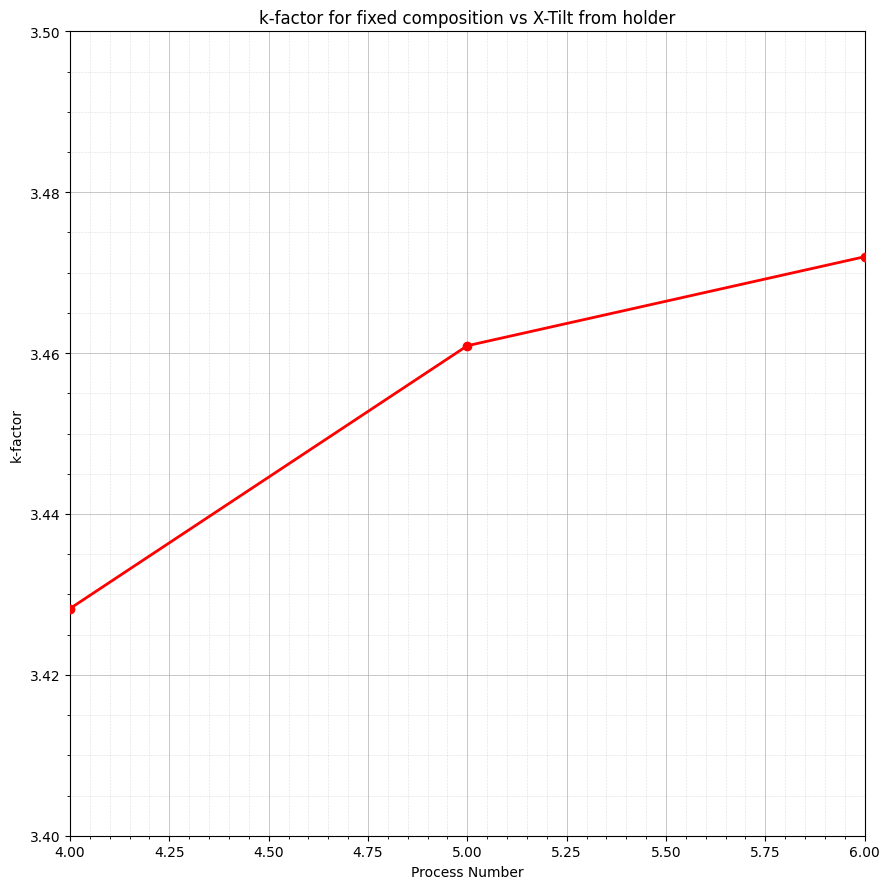

In [11]:
# ================================================================================================== k-factor Calculation with Plot =================================================================================================================

results = []

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE

Calibration_Factor = 3.66875 # Mass ratio of Ni and O 58.70/16.00 = 3.66875

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE 

k_ONi_theory = (k_factors["O_Ka"] / k_factors["Ni_Ka"]) * Calibration_Factor

print("k_(O_Ka/Ni_Ka) =", k_factors["O_Ka"], ", k_(Ni_Ka/O_Ka) =", k_factors["Ni_Ka"], ", k_(O_Ka/Ni_Ka)_Calibrated =", k_ONi_theory)
print()

# fixed composition
Ni_Composition = 50
O_Composition = 50

# calculate k-factor for each fit result

for fit in fit_results:
    area_ni = fit["Ni_Ka_area"]
    area_o = fit["O_Ka_area"]

    # because Ni/O composition is fixed to 50/50:
    # O/Ni = 1 = k_ONi * (O_Ka/Ni_Ka)
    k_ONi = area_ni / area_o

    results.append({
        "file": fit["file"].name,
        "process": fit["process"],
        "Ni_Ka": area_ni,
        "O_Ka": area_o,
        "Ni_comp": Ni_Composition,
        "O_comp": O_Composition,
        "k_ONi": k_ONi,
    })

    print(
        f"{fit['file'].name:10}  "
        f"Ni_Ka_Area={area_ni:.1f}, "
        f"O_Ka_Area={area_o:.1f}, "
        f"O_Ka/Ni_Ka={area_o/area_ni:.3f}, "
        f"k_ONi={k_ONi:.4f}"
    )


ni_area_avg = np.mean([r["Ni_Ka"] for r in results])
o_area_avg = np.mean([r["O_Ka"] for r in results])
k_ONi_avg = np.mean([r["k_ONi"] for r in results])

print()
print(
    f"{'AVERAGE':10}  "

    f"Ni_Ka_Area={ni_area_avg:.1f}, "
    f"O_Ka_Area={o_area_avg:.1f}, "
    f"O_Ka/Ni_Ka={o_area_avg/ni_area_avg:.3f}, "
    f"k_ONi_avg={k_ONi_avg:.4f}"
)# ================================================================================================== Angle Dependence k-Factor Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results = sorted(results, key=lambda r: r["process"])

process = [r["process"] for r in results]
k_values = [r["k_ONi"] for r in results]

fig, ax1 = plt.subplots(figsize=(9, 9))

center = 3.45
CenteringRange = 0.05
ymin = center - CenteringRange
ymax = center + CenteringRange

ax1.set_ylim(ymin, ymax)
ax1.set_xlim(4, 6)

ymin, ymax = ax1.get_ylim()


ax1.plot(process, k_values, marker="o", linewidth=2, color="red", zorder=3)

ax1.set_xlabel("Process Number")
ax1.set_ylabel("k-factor")
ax1.set_title(f"k-factor for fixed composition vs X-Tilt from holder")

ax1.minorticks_on()
ax1.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax1.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)

ax1.axvline(0, color="grey", linestyle="--", linewidth=1)






plt.tight_layout()
# plt.savefig(PlotPath / f"kFactorVsAngle_{timestamp}.pdf")
plt.show()

<center>

# Energy Resolution

</center>

$$\triangle(Mn) \approx 0.926 FWHM(Ni_{K\alpha})$$

The detectors ability to distinguish different X-ray lines from each other. Typical value is 130 eV.

Process =   4.00°   FWHM(Ni_Ka) = 144.4991 eV   Mn Kα-equivalent resolution = 133.8062 eV
Process =   5.00°   FWHM(Ni_Ka) = 141.5293 eV   Mn Kα-equivalent resolution = 131.0561 eV
Process =   6.00°   FWHM(Ni_Ka) = 141.9066 eV   Mn Kα-equivalent resolution = 131.4055 eV

Average Mn Kα-equivalent resolution = 132.1 eV


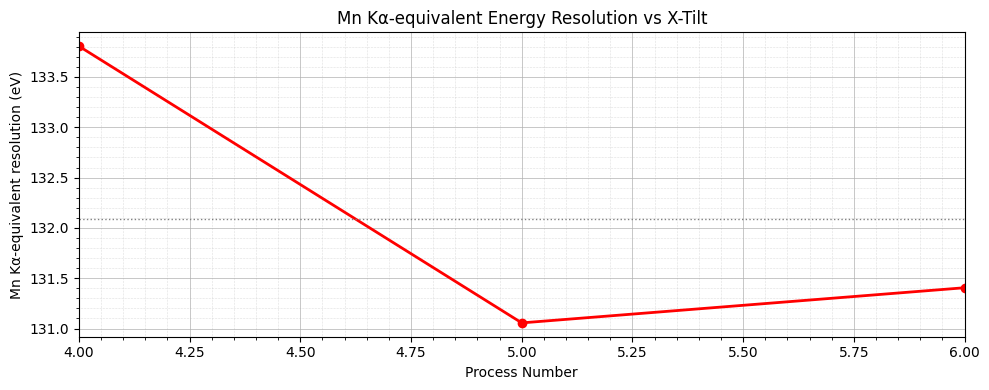

In [12]:
# ================================================================================================== Energy Resolution Plot =================================================================================================================

results_resolution = []

for fit in fit_results:
    process = fit["process"]
    sig_Ni_Ka = fit["Ni_Ka_sig"]

    FWHM_Ni_Ka = 2 * np.sqrt(2*np.log(2)) * sig_Ni_Ka
    Mn_equivalent_resolution = 0.926 * FWHM_Ni_Ka

    results_resolution.append({"process": process, "FWHM_Ni_Ka": FWHM_Ni_Ka, "Mn_equivalent_resolution": Mn_equivalent_resolution})

    print(f"Process = {process:6.2f}°   " f"FWHM(Ni_Ka) = {FWHM_Ni_Ka*1000:.4f} eV   " f"Mn Kα-equivalent resolution = {Mn_equivalent_resolution*1000:.4f} eV")

mn_avg = np.mean([r["Mn_equivalent_resolution"] for r in results_resolution])

print()
print(f"Average Mn Kα-equivalent resolution = {mn_avg * 1000:.1f} eV")


# ================================================================================================== Energy Resolution vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_resolution = sorted(results_resolution, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_resolution])
mn_resolution = np.array([r["Mn_equivalent_resolution"] for r in results_resolution])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(processes, mn_resolution * 1000, marker="o", linewidth=2, color="red")
ax.set_xlabel("Process Number")
ax.set_ylabel("Mn Kα-equivalent resolution (eV)")
#ax.set_ylim(133.2, 134.5)
ax.set_xlim(4, 6)
ax.set_title("Mn Kα-equivalent Energy Resolution vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(mn_avg*1000, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"MnResolutionVsAngle_{timestamp}.pdf")
plt.show()

<center>

# Peak Shape

</center>

$$ S=\frac{FWTM(Ni_{K\alpha})}{FWHM(Ni_{K\alpha})} $$
For a perfect Gaussian peak:
$$S_{Gaussien}=\sqrt{\frac{ln(10)}{ln(2)}}\approx 1.823$$


  Values > 2.0 may indicate peak tailing, due to incomplete charge collection.

Process =   4.00   FWHM(Ni_Ka) = 144.0801 eV   FWTM(Ni_Ka) = 264.0537 eV   Shape factor (S) = 1.833
Process =   5.00   FWHM(Ni_Ka) = 140.9944 eV   FWTM(Ni_Ka) = 258.6117 eV   Shape factor (S) = 1.834
Process =   6.00   FWHM(Ni_Ka) = 141.7944 eV   FWTM(Ni_Ka) = 259.5562 eV   Shape factor (S) = 1.831

Average PeakShape factor (S) = 1.832


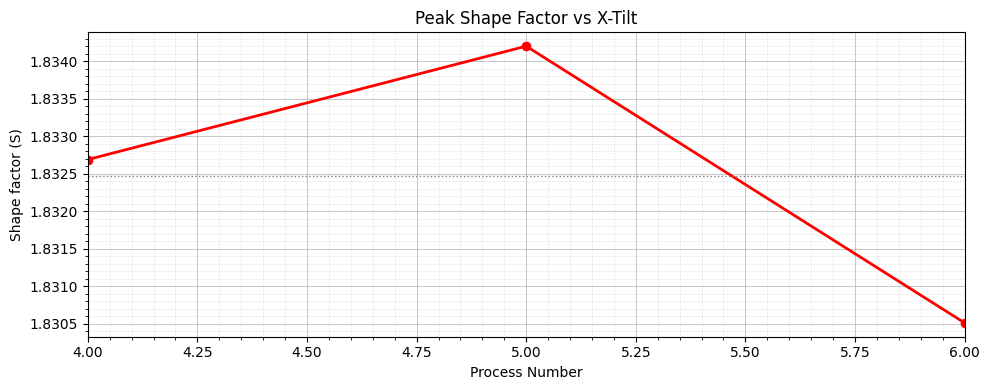

In [13]:
# ================================================================================================== Peak Shape Factor Plot =================================================================================================================

results_shape = []

for fit in fit_results:
    Process = fit["process"]
    FWHM_Ni_Ka = fit["Ni_Ka_FWHM_data"]
    FWTM_Ni_Ka = fit["Ni_Ka_FWTM_data"]
    S = FWTM_Ni_Ka / FWHM_Ni_Ka

    results_shape.append({"process": Process, "FWHM_Ni_Ka": FWHM_Ni_Ka, "FWTM_Ni_Ka": FWTM_Ni_Ka, "S": S})

    print(f"Process = {Process:6.2f}   " f"FWHM(Ni_Ka) = {FWHM_Ni_Ka*1000:.4f} eV   " f"FWTM(Ni_Ka) = {FWTM_Ni_Ka*1000:.4f} eV   " f"Shape factor (S) = {S:.3f}")

S_avg = np.mean([r["S"] for r in results_shape])

print()
print(f"Average PeakShape factor (S) = {S_avg:.3f}")


# ================================================================================================== Peak Shape Factor vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_shape = sorted(results_shape, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_shape])
S_values = np.array([r["S"] for r in results_shape])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(processes, S_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Process Number")
ax.set_ylabel("Shape factor (S)")
ax.set_xlim(4, 6)
ax.set_title("Peak Shape Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(S_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"ShapeFactorVsAngle_{timestamp}.pdf")
plt.show()

<center>

# Stray Radiation
</center>

$$ R_{Ni_{K \alpha}/Mo_{K \alpha }} = \frac{I(Ni_{K \alpha})}{I(Mo_{K \alpha })}$$

Expected to be between 3-7

Process =   4.00   R_Ni_Mo = 3.479
Process =   5.00   R_Ni_Mo = 3.509
Process =   6.00   R_Ni_Mo = 3.547

Average Stray Radiation factor (R) = 3.512


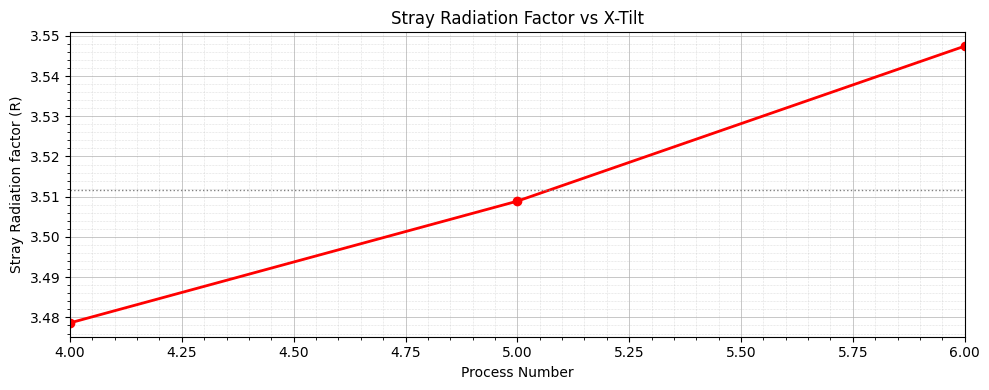

In [14]:
# ================================================================================================== Stray Radiation Plot =================================================================================================================

results_stray= []

for fit in fit_results:
    Process = fit["process"]
    Ni_Ka_area = fit["Ni_Ka_area"]
    Mo_Ka_area = fit["Mo_Ka_area"]
    R_Ni_Mo = Ni_Ka_area / Mo_Ka_area

    results_stray.append({"process": Process, "R_Ni_Mo": R_Ni_Mo})

    print(f"Process = {Process:6.2f}   " f"R_Ni_Mo = {R_Ni_Mo:.3f}")

R_Ni_Mo_avg = np.mean([r["R_Ni_Mo"] for r in results_stray])

print()
print(f"Average Stray Radiation factor (R) = {R_Ni_Mo_avg:.3f}")


# ================================================================================================== Stray Radiation vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_stray = sorted(results_stray, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_stray])
R_values = np.array([r["R_Ni_Mo"] for r in results_stray])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(processes, R_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Process Number")
ax.set_ylabel("Stray Radiation factor (R)")
ax.set_xlim(4, 6)
ax.set_title("Stray Radiation Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_Ni_Mo_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"StrayRadiationFactorVsAngle_{timestamp}.pdf")
plt.show()

<center>

# Source of Stray Radiation
</center>

$$ R_{Mo_{K \alpha}/Mo_{L \alpha }} = \frac{I(Mo_{K \alpha})}{I(Mo_{L \alpha })}$$

High ratio (order of 100) indicates X-rays are main source of column radiation. If high energy electrons are predominant, the value is lower in the order of 1-10.

Process =   4.00   R_MoK_MoL = 2.370
Process =   5.00   R_MoK_MoL = 2.420
Process =   6.00   R_MoK_MoL = 2.419

Average Stray Radiation Source factor (R) = 2.403


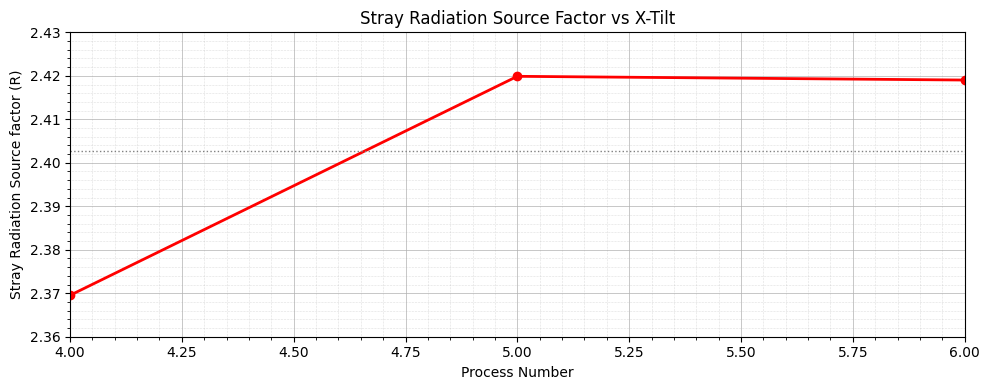

In [15]:
# ================================================================================================== Stray Radiation Source Plot ===========================================================================================================

results_straysource= []

for fit in fit_results:
    process = fit["process"]
    Mo_Ka_area = fit["Mo_Ka_area"]
    Mo_La_area = fit["Mo_La_area"]
    R_MoK_MoL =Mo_Ka_area / Mo_La_area

    results_straysource.append({"process": process, "R_MoK_MoL": R_MoK_MoL})

    print(f"Process = {process:6.2f}   " f"R_MoK_MoL = {R_MoK_MoL:.3f}")

R_MoK_MoL_avg = np.mean([r["R_MoK_MoL"] for r in results_straysource])

print()
print(f"Average Stray Radiation Source factor (R) = {R_MoK_MoL_avg:.3f}")


# ================================================================================================== Stray Radiation Source vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_straysource = sorted(results_straysource, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_straysource])
R_values = np.array([r["R_MoK_MoL"] for r in results_straysource])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(processes, R_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Process Number")
ax.set_ylabel("Stray Radiation Source factor (R)")
ax.set_xlim(4, 6)
ax.set_ylim(2.36, 2.43)
ax.set_title("Stray Radiation Source Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_MoK_MoL_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"StrayRadiationSourceFactorVsAngle_{timestamp}.pdf")
plt.show()

<center>

# Fiori Number ->  P/B Characteristics
</center>

$$ P/B_{10}= 60\cdot \frac{I(Ni_{K \alpha})}{B(Ni_{K \alpha })}\geq 1000 $$

$B_{10}=B_{600}/60$ Which Means the Background we use is the Average Background (whithout Peakarea) of one Channel over a Windwo width of 600eV


<!-- ATTENTION!

$$ \operatorname{erf}\left(\frac{2}{\sqrt{2}}\right)= 0.9545 $$

$$\sigma=\frac{FWHM}{2\sqrt{2\cdot ln(2)}}$$

X-Boundary for the Background

$$E_{1;2}=E_{Ni_{K\alpha}}\pm 2\cdot \sigma -->

Process = 4, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.142,  PB = 2877.252
Process = 5, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.142,  PB = 2871.515
Process = 6, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.472, FWHM = 0.142,  PB = 2879.468

Average Stray Radiation factor (R) = 2876.078


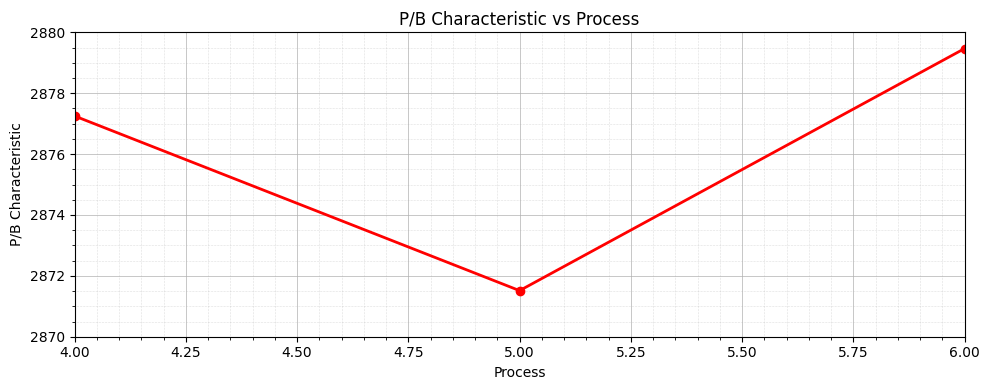

In [16]:
# ================================================================================================== P/B Characteristic Plot ==============================================================================================================


results_PBcharacteristics= []

E_N_Ka_true = s._get_line_energy("Ni_Ka")



for fit in fit_results:
    process = fit["process"]
    window=0.6
    x_Ni_bg_left = fit["Ni_Ka_mu"] - window/2
    x_Ni_bg_right = fit["Ni_Ka_mu"] + window/2

    bg_region = (x >= x_Ni_bg_left) & (x <= x_Ni_bg_right)
    total_background = (np.trapezoid(np.polyval(p_Ni, x[bg_region]), x[bg_region]) * KeV_per_channel) 
    Ni_Ka_area = fit["Ni_Ka_area"]* math.erf( 2 / math.sqrt(2))  #the first two means 2Simga equals 95.4% of the peak area, and the last term is the error function to account for the Gaussian distribution of the peak
    PB = 60*Ni_Ka_area / total_background

    results_PBcharacteristics.append({"process": process, "PB": PB})

    print(f"Process = {process}, Literature Energy Ni_Ka = {E_N_Ka_true:.3f}, Experimental Energy Ni_Ka = {fit["Ni_Ka_mu"]:.3f}, FWHM = {FWHM_Ni_Ka:.3f},  PB = {PB:.3f}")

PB_avg = np.mean([r["PB"] for r in results_PBcharacteristics])

print()
print(f"Average Stray Radiation factor (R) = {PB_avg:.3f}")

# ================================================================================================== P/B Characeristics vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_PBcharacteristics = sorted(results_PBcharacteristics, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_PBcharacteristics])
PB_values = np.array([r["PB"] for r in results_PBcharacteristics])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(processes, PB_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Process")
ax.set_ylabel("P/B Characteristic")
ax.set_title("P/B Characteristic vs Process")
ax.minorticks_on()
ax.set_xlim(4, 6)
ax.set_ylim(2870, 2880)
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_Ni_Mo_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"PBCharacteristicsVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp

<center>

# Contamination or Icing of Detector
</center>

$$ R_{Ni_{K \alpha}/Ni_{L \alpha }} = \frac{I(Ni_{K \alpha})}{I(Ni_{L \alpha })}$$

Process =   4.00   R_NiK_NiL = 1.464
Process =   5.00   R_NiK_NiL = 1.472
Process =   6.00   R_NiK_NiL = 1.472

Average Contamination factor (R) = 1.469


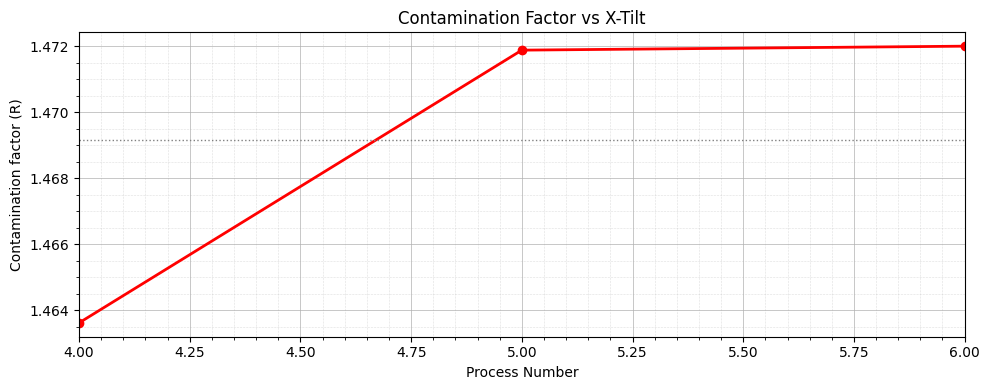

In [17]:
# ================================================================================================== Contanimation Plot ===========================================================================================================

results_contanimation= []

for fit in fit_results:
    process = fit["process"]
    Ni_Ka_area = fit["Ni_Ka_area"]
    Ni_La_area = fit["Ni_La_area"]
    R_NiK_NiL = Ni_Ka_area / Ni_La_area

    results_contanimation.append({"process": process, "R_NiK_NiL": R_NiK_NiL})

    print(f"Process = {process:6.2f}   " f"R_NiK_NiL = {R_NiK_NiL:.3f}")

R_NiK_NiL_avg = np.mean([r["R_NiK_NiL"] for r in results_contanimation])

print()
print(f"Average Contamination factor (R) = {R_NiK_NiL_avg:.3f}")


# ================================================================================================== Contamination vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_contanimation = sorted(results_contanimation, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_contanimation])
R_values = np.array([r["R_NiK_NiL"] for r in results_contanimation])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(processes, R_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Process Number")
ax.set_ylabel("Contamination factor (R)")
ax.set_xlim(4, 6)
ax.set_title("Contamination Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_NiK_NiL_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"ContaminationFactorVsAngle_{timestamp}.pdf")
plt.show()

<center>

# Peak Area vs. Process time   


</center>


Peak areas:
 Process     O_Ka_area    Ni_Ka_area   Ni_Kb_area    Ni_La_area    Mo_Ka_area   Mo_La_area
       4 153421.090637 525965.027079 76103.905275 359359.589371 151198.516226 63809.576798
       5 151669.702800 524916.206079 75625.958166 356628.612068 149595.811377 61819.369319
       6 151605.176718 526370.025093 75667.034761 357587.093900 148381.325050 61339.220001


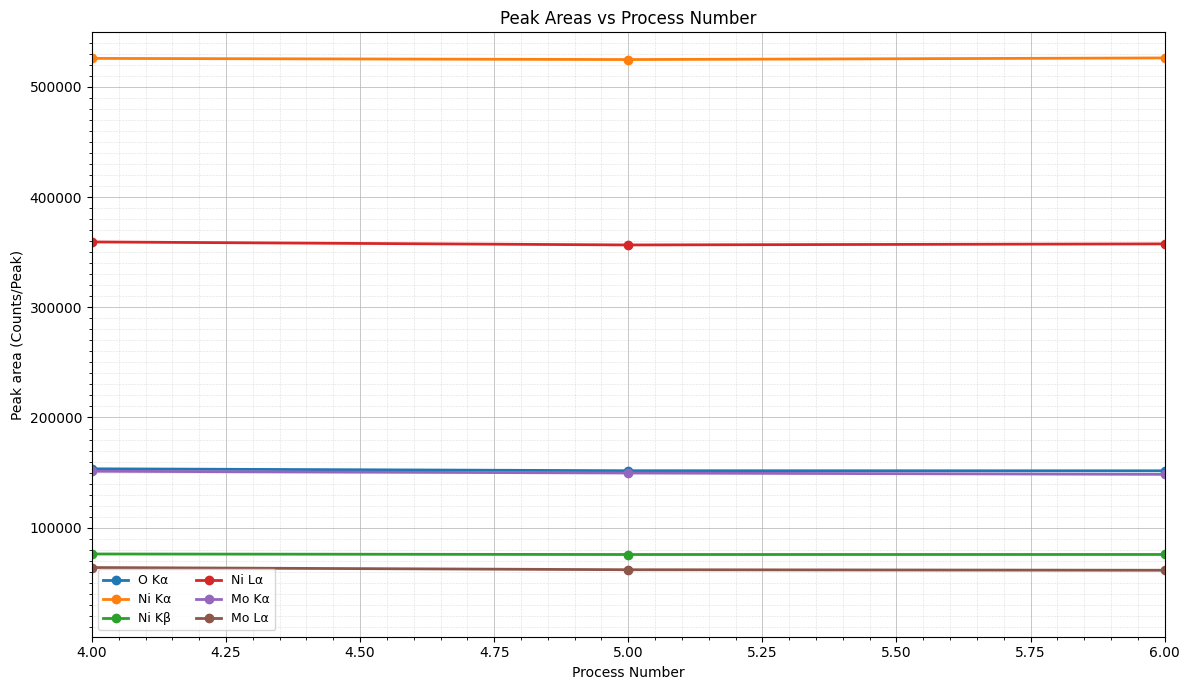

In [18]:
# ==================================================================================================Peak Area vs Angle Plot==================================================================================================

results_peakareas = []

for fit in fit_results:
    results_peakareas.append({
        "process": fit["process"],
        "O_Ka_area": fit["O_Ka_area"],
        "Ni_Ka_area": fit["Ni_Ka_area"],
        "Ni_Kb_area": fit["Ni_Kb_area"],
        "Ni_La_area": fit["Ni_La_area"],
        "Mo_Ka_area": fit["Mo_Ka_area"],
        "Mo_La_area": fit["Mo_La_area"]
    })

results_peakareas = sorted(results_peakareas, key=lambda r: r["process"])

processes = np.array([r["process"] for r in results_peakareas])

O_Ka_area  = np.array([r["O_Ka_area"] for r in results_peakareas])
Ni_Ka_area = np.array([r["Ni_Ka_area"] for r in results_peakareas])
Ni_Kb_area = np.array([r["Ni_Kb_area"] for r in results_peakareas])
Ni_La_area = np.array([r["Ni_La_area"] for r in results_peakareas])
Mo_Ka_area = np.array([r["Mo_Ka_area"] for r in results_peakareas])
Mo_La_area = np.array([r["Mo_La_area"] for r in results_peakareas])

# ---- print values as table ----
peakareas_df = pd.DataFrame({
    "Process": processes,
    "O_Ka_area": O_Ka_area,
    "Ni_Ka_area": Ni_Ka_area,
    "Ni_Kb_area": Ni_Kb_area,
    "Ni_La_area": Ni_La_area,
    "Mo_Ka_area": Mo_Ka_area,
    "Mo_La_area": Mo_La_area,
})

print("\nPeak areas:")
print(peakareas_df.to_string(index=False))

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(processes, O_Ka_area,  marker="o", linewidth=2, label="O Kα")
ax.plot(processes, Ni_Ka_area, marker="o", linewidth=2, label="Ni Kα")
ax.plot(processes, Ni_Kb_area, marker="o", linewidth=2, label="Ni Kβ")
ax.plot(processes, Ni_La_area, marker="o", linewidth=2, label="Ni Lα")
ax.plot(processes, Mo_Ka_area, marker="o", linewidth=2, label="Mo Kα")
ax.plot(processes, Mo_La_area, marker="o", linewidth=2, label="Mo Lα")

ax.set_xlabel("Process Number")
ax.set_ylabel("Peak area (Counts/Peak)")
ax.set_title("Peak Areas vs Process Number")

ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)

ax.axvline(0, color="grey", linestyle="--", linewidth=1)

ax.legend(ncol=2, fontsize=9)
ax.set_yscale("linear")
ax.set_ylim(bottom=1000)
ax.set_xlim(4, 6)
ax.yaxis.set_minor_locator(MultipleLocator(10000))

plt.tight_layout()
# plt.savefig(PlotPath / f"PeakAreasVsProcess_{timestamp}.pdf")
plt.show()